# Model Explainability

## Objectives

- Train the tuned Random Forest model.
- Visualize feature importance.
- Explain predictions using SHAP values.

In [1]:
%pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/41.9 MB 42.3 MB/s eta 0:00:01
   ---- ----------------------------------- 4.2/41.9 MB 12.6 MB/s eta 0:00:03
   ---- ----------------------------------- 4.5/41.9 MB 7.9 MB/s eta 0:00:05
   ---- ----------------------------------- 4.5/41.9 MB 7.9 MB/s eta 0:00:05
   ---- ----------------------------------- 4.7/41.9 MB 4.4 MB/s eta 0:00:09
   ---- ----------------------------------- 4.7/41.9 MB 4.4 MB/s eta 0:00:09
   ----- ---------------------------------- 5.2/41.9 MB 3.5 MB/s eta 0:00:11
   ----- ---------------------------------- 6.0/41.9 MB 3.4 MB/s eta 0:00:11
   ------ --------------------------------- 7.1/41.9 MB 3.6 MB/s eta 0:00:10
   ------- -------------------------------- 7.3/41.9 MB 3.5 MB/s eta 0:00:10
   ------- -------------------------------- 7.9/41.9 MB 3.2 MB/s eta 0:00:11
   ------- -------------------------------- 8.1/41.9 MB 3.2 MB/s eta 0:00:11
   -

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestClassifier

In [4]:
stock = pd.read_csv(
    "../data/processed/reliance_advanced_features.csv",
    parse_dates=["Date"]
)

stock.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Trading_Range,...,MA200,EMA20,Target,RSI,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Width,Momentum10
0,2015-11-20,204.222931,216.433975,217.794052,211.565155,213.496689,11304265,0.012945,0.012862,6.228897,...,208.368368,213.480029,1,51.550482,-1.221252,-1.031852,221.865864,209.212293,12.653571,-1.017197
1,2015-11-23,205.711151,218.011200,218.959824,216.285400,217.154022,10499517,0.007287,0.007261,2.674423,...,208.396198,213.911569,1,51.601790,-0.842501,-0.993982,221.826597,209.222987,12.603610,3.920197
2,2015-11-24,208.720001,221.199936,222.091415,217.394028,217.839767,14806176,0.014626,0.014521,4.697388,...,208.456144,214.605699,1,52.071310,-0.281785,-0.851542,222.342142,208.982884,13.359258,3.497314
3,2015-11-26,213.238602,225.988754,226.743088,221.325668,221.954269,23805828,0.021649,0.021418,5.417419,...,208.548263,215.689800,0,55.250916,0.542747,-0.572684,224.304350,208.067586,16.236764,6.263168
4,2015-11-27,211.168030,223.794357,226.868805,222.662872,226.068756,10891864,-0.009710,-0.009758,4.205933,...,208.595637,216.461662,0,57.009350,1.007512,-0.256645,225.401663,207.873177,17.528486,12.869232


In [5]:
features = [
    "Daily_Return",
    "Log_Return",
    "Trading_Range",
    "Price_Change",
    "Volatility20",
    "MA20",
    "MA50",
    "MA200",
    "EMA20",
    "RSI",
    "MACD",
    "MACD_Signal",
    "BB_Upper",
    "BB_Lower",
    "BB_Width",
    "Momentum10"
]

X = stock[features]
y = stock["Target"]

In [6]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [7]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,RSI,0.074631
15,Momentum10,0.074143
4,Volatility20,0.072249
2,Trading_Range,0.071396
14,BB_Width,0.070144
3,Price_Change,0.069565
1,Log_Return,0.066962
0,Daily_Return,0.065336
10,MACD,0.062885
11,MACD_Signal,0.062838


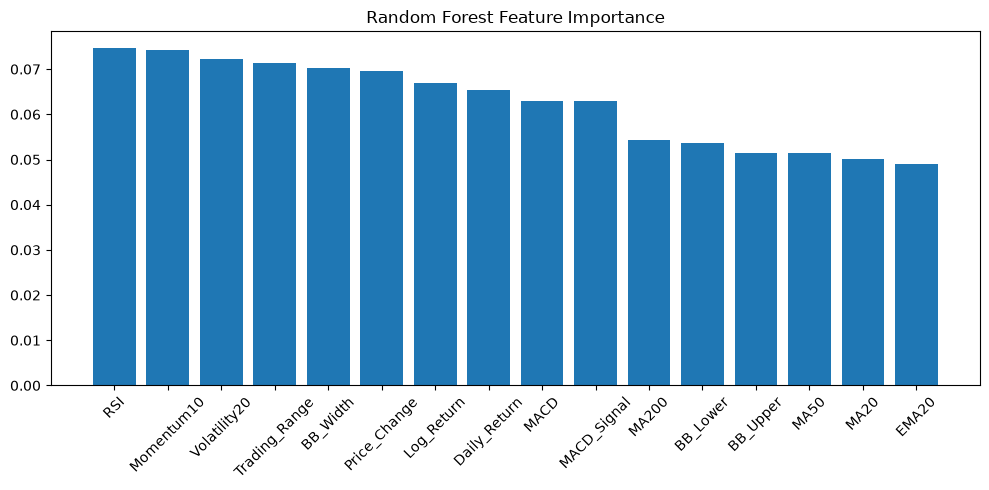

In [8]:
plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()

In [9]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

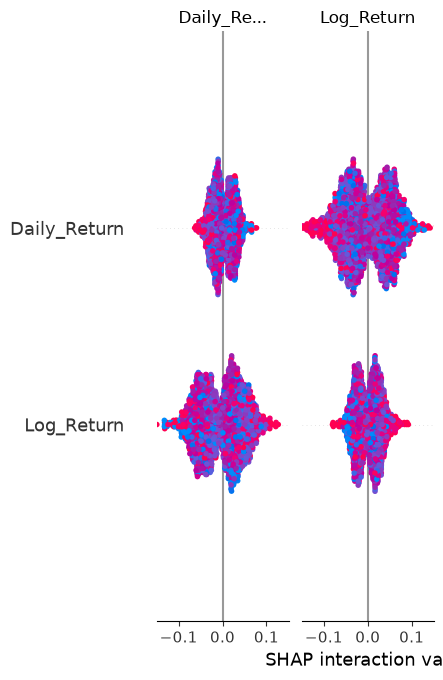

In [10]:
shap.summary_plot(
    shap_values,
    X
)

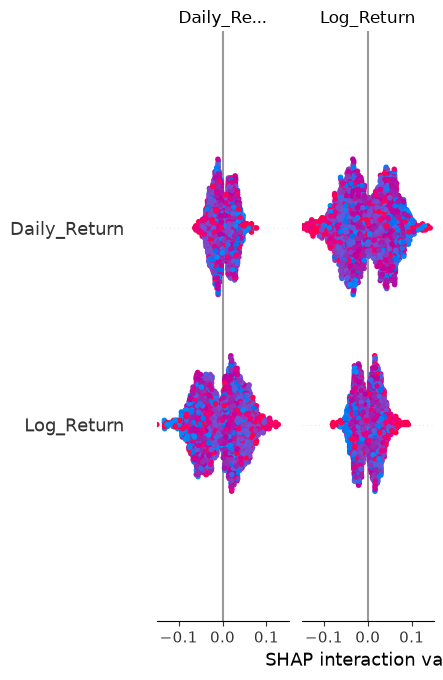

In [11]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

## Conclusion

### Key Findings

- Random Forest feature importance identified the most influential technical indicators.
- SHAP values provided both global and local explanations for model predictions.
- Model explainability improves transparency and helps build trust in AI-based investment decisions.